# Urban Heat Island (UHI) Benchmark Notebook 

## Model Objective:

The objective of this notebook is to build a machine learning model to predict <b>Urban Heat Island (UHI) intensity levels</b> across urban environments. The goal is to develop a classification model that can categorize UHI intensity into three discrete classes: <b>Low</b>, <b>Moderate</b>, and <b>High</b>, based on spatial and contextual geospatial data.

<p align="justify">This reference notebook is designed as a practical learning resource for students to explore how machine learning techniques can be applied to geospatial and satellite data for classifying Urban Heat Island (UHI) intensity into three categories: <b>Low</b>, <b>Medium</b>, and <b>High</b>. It guides students through the complete modeling workflow—from data preparation to prediction—using real-world datasets.</p>

<p align="justify">To capture urban surface conditions, the notebook derives multiple spectral indices from <a href="https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a#Example-Notebook">Sentinel-2 Level-2A</a> 90-day cloud-free median mosaics: <b>NDVI</b> (vegetation), <b>NDBI</b> (built-up), <b>NDWI</b> and <b>MNDWI</b> (water), <b>Albedo</b> (surface heat absorption), <b>BSI</b> (bare soil / informal settlements), <b>FVC</b> (fractional vegetation cover), and <b>IBI</b> (composite built-up index). Multi-scale spatial context is captured by extracting each index at both a 50m local buffer and a 500m neighbourhood buffer, with local deviation features (local − neighbourhood) added as self-normalising cross-city signals. GLCM texture features (contrast, homogeneity, energy, correlation) are computed from the NDBI band to capture structural heterogeneity. Building density within 50m and 100m buffers is derived from the <a href="https://zenodo.org/records/13694392">3D-GloBFP dataset</a>.</p>

<p align="justify">The training dataset consists of labelled UHI points from Santiago, Chile and Rio de Janeiro, Brazil. The trained model is validated on Freetown, Sierra Leone — an unseen city with a different climate and urban morphology, testing the model's cross-city generalisation ability.</p>

<p align="justify">The classification model is an <b>XGBoost</b> gradient-boosted tree classifier trained on the 25-feature set described above. Class imbalance is handled via inverse-frequency sample weights. Per-city z-score normalisation is applied to spectral features to remove city-wide baseline differences before training and prediction.</p>

## Load In Dependencies

In [2]:
# Install missing package required for this notebook (run once per environment)
#%pip install geopandas pyproj rasterio rioxarray xarray pystac_client planetary_computer scikit-learn tqdm matplotlib seaborn scikit-image

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets (e.g., NetCDF, Zarr)
import xarray as xr

# Geospatial raster data handling with CRS support
import rioxarray as rxr

# Geospatial vector data handling (e.g., shapefiles, GeoJSON)
import geopandas as gpd
from shapely.geometry import box, Point

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Raster operations and spatial windowing
import rasterio
from rasterio.windows import from_bounds

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Machine learning model and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Planetary Computer tools for STAC API access and authentication
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# Progress bar for loops
from tqdm import tqdm

# SMOTE for class balancing (kept for reference; removed in Trial 06+)
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# GLCM texture features
from skimage.feature import graycomatrix, graycoprops

The ground-based temperature data has been put into 3 categories: Low, Medium and High. These categories represent the intensity of the urban heat island effect. For example, the LOW category represents temperatures that are more than 2% below the mean. The HIGH category represents temperatures that are more than 2% above the mean. The MEDIUM category represents temperatures within 2% of the mean. These 3 classes are used to simplify the modeling process while still identifying the regions of HIGH temperatures coincident with urban heat islands. 

## Response Variable

Before building the model, we first load the Urban Heat Island (UHI) Intensity classification training datasets curated for Santiago (Chile) and Rio de Janeiro (Brazil). This dataset includes geo-referenced points (latitude and longitude)and the UHI class, which categorizes the heat intensity at each location into Low, Medium, or High. This labeled dataset forms the basis for training our classification model, which will later be used to predict UHI intensity classes in Freetown, Sierra Leone.

In [3]:
chile_heat_df=pd.read_csv('./Data/sample_chile_uhi_data.csv')
chile_heat_df.head()

,Longitude,Latitude,UHI_Class
0,-70.580508,-33.586980,Low
1,-70.579480,-33.592099,Low
2,-70.578366,-33.597419,Medium
3,-70.566661,-33.597109,Low
4,-70.566296,-33.597079,Medium


In [4]:
Brazil_heat_df=pd.read_csv('./Data/sample_Brazil_uhi_data.csv')
Brazil_heat_df.head()

,Longitude,Latitude,UHI_Class
0,-43.278320,-22.901192,Medium
1,-43.278298,-22.901215,Medium
2,-43.278277,-22.901235,Medium
3,-43.278218,-22.901298,Medium
4,-43.278185,-22.901335,Medium


## Predictor Variables

In [ ]:
def extract_band_vales(geotiff_path, csv_input_path, buffer_m=50,
                       neighborhood_m=500,
                       glcm_patch_px=15, glcm_band=2, glcm_levels=32):
    """
    Extracts multi-scale spectral features AND GLCM texture in a single raster pass.

    GeoTIFF band layout (7 bands):
      1=NDVI  2=NDBI  3=NDWI  4=MNDWI  5=Albedo  6=BSI  7=FVC

    Per point, extracts:
      - Local mean  : mean within `buffer_m` (50m)  → median_X
      - Neighborhood mean : mean within `neighborhood_m` (500m) → neigh_X
      - Local deviation   : local - neighborhood     → dev_X
        (deviation is already city-relative, no further normalisation needed)
      - GLCM texture features from NDBI band over a ~150m patch

    IBI is derived from local NDVI / NDBI / NDWI after extraction.
    """
    df = pd.read_csv(csv_input_path)
    band_names = ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Albedo', 'BSI', 'FVC']
    glcm_props = ['contrast', 'homogeneity', 'energy', 'correlation']

    with rasterio.open(geotiff_path) as src:
        pixel_m = abs(src.transform[0]) * 111320.0
        half_px = max(1, int(buffer_m      / pixel_m / 2))   # 50m local
        half_n  = max(1, int(neighborhood_m / pixel_m / 2))  # 500m neighborhood
        half_g  = glcm_patch_px // 2

        spec_res  = {f'median_{b}': [] for b in band_names}
        neigh_res = {f'neigh_{b}': []  for b in band_names}
        glcm_res  = {f'glcm_{p}': []  for p in glcm_props}

        for lat, lon in tqdm(zip(df['Latitude'], df['Longitude']),
                              total=len(df), desc="Multi-scale extraction"):
            try:
                row, col = src.index(lon, lat)

                # ── Read large 500m window once ───────────────────────────
                n_win = rasterio.windows.Window(
                    col - half_n, row - half_n,
                    2 * half_n + 1, 2 * half_n + 1
                )
                n_patch = src.read(window=n_win).astype("float32")
                n_patch[n_patch == 0] = np.nan

                # Slice inner 50m region from the large window
                cx = half_n  # centre pixel within large patch
                l_patch = n_patch[
                    :,
                    cx - half_px: cx + half_px + 1,
                    cx - half_px: cx + half_px + 1
                ]

                for i, b in enumerate(band_names):
                    # Local 50m mean
                    lv = l_patch[i]
                    spec_res[f'median_{b}'].append(
                        float(np.nanmean(lv)) if np.any(np.isfinite(lv)) else np.nan
                    )
                    # Neighborhood 500m mean
                    nv = n_patch[i]
                    neigh_res[f'neigh_{b}'].append(
                        float(np.nanmean(nv)) if np.any(np.isfinite(nv)) else np.nan
                    )

                # ── GLCM texture (NDBI band, ~150m patch) ─────────────────
                g_win = rasterio.windows.Window(
                    col - half_g, row - half_g,
                    glcm_patch_px, glcm_patch_px
                )
                g_patch = src.read(glcm_band, window=g_win).astype('float32')
                g_patch[g_patch == 0] = np.nan

                if (np.all(np.isnan(g_patch)) or
                        g_patch.shape != (glcm_patch_px, glcm_patch_px)):
                    for p in glcm_props:
                        glcm_res[f'glcm_{p}'].append(np.nan)
                else:
                    med = float(np.nanmedian(g_patch))
                    g_patch = np.where(np.isnan(g_patch), med, g_patch)
                    p_min, p_max = g_patch.min(), g_patch.max()
                    if p_max - p_min < 1e-8:
                        for p in glcm_props:
                            glcm_res[f'glcm_{p}'].append(np.nan)
                    else:
                        q = ((g_patch - p_min) / (p_max - p_min) *
                             (glcm_levels - 1)).astype('uint8')
                        glcm_mat = graycomatrix(
                            q, distances=[1],
                            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=glcm_levels, symmetric=True, normed=True
                        )
                        for p in glcm_props:
                            glcm_res[f'glcm_{p}'].append(
                                float(graycoprops(glcm_mat, p).mean())
                            )

            except Exception:
                for b in band_names:
                    spec_res[f'median_{b}'].append(np.nan)
                    neigh_res[f'neigh_{b}'].append(np.nan)
                for p in glcm_props:
                    glcm_res[f'glcm_{p}'].append(np.nan)

    for key, vals in spec_res.items():
        df[key] = vals
    for key, vals in neigh_res.items():
        df[key] = vals
    for key, vals in glcm_res.items():
        df[key] = vals

    # IBI derived from local means
    ndbi = df['median_NDBI']
    ndvi = df['median_NDVI']
    ndwi = df['median_NDWI']
    df['median_IBI'] = (2*ndbi - (ndvi + ndwi)) / (2*ndbi + (ndvi + ndwi) + 1e-10)

    # Local deviation features — how different is this point from its 500m context?
    # These are already city-relative so they DON'T need per-city normalisation.
    for b in ['NDVI', 'NDBI', 'Albedo', 'BSI']:
        df[f'dev_{b}'] = df[f'median_{b}'] - df[f'neigh_{b}']

    return df

In [9]:
chile_heat_data = extract_band_vales(geotiff_path="./sample_chile.tiff", csv_input_path="./Data/sample_chile_uhi_data.csv")
chile_heat_data.head()

Spectral + GLCM extraction: 100%|██████████| 21662/21662 [00:09<00:00, 2279.29it/s]


,Longitude,Latitude,UHI_Class,median_NDVI,median_NDBI,median_NDWI,median_MNDWI,median_Albedo,median_BSI,median_FVC,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,median_IBI
0,-70.580508,-33.586980,Low,0.134889,0.014254,-0.174616,-0.188553,0.236102,0.048278,0.014411,17.794558,0.335558,0.108512,0.446717,-6.082390
1,-70.579480,-33.592099,Low,0.128323,0.009258,-0.164349,-0.173508,0.220982,0.044352,0.012973,20.956378,0.306299,0.081738,0.834474,-3.114891
2,-70.578366,-33.597419,Medium,0.050916,0.050965,-0.085407,-0.135698,0.226447,0.062838,0.000340,52.811820,0.248696,0.080677,0.386607,2.022917
3,-70.566661,-33.597109,Low,0.119861,0.092615,-0.144284,-0.233338,0.327139,0.084146,0.018684,62.630357,0.169274,0.077052,0.307206,1.303756
4,-70.566296,-33.597079,Medium,0.098381,0.088432,-0.133731,-0.219053,0.281648,0.083990,0.010547,54.262840,0.180833,0.077160,0.260637,1.499594


In [10]:
Brazil_heat_data = extract_band_vales(geotiff_path="./sample_Brazil.tiff", csv_input_path="./Data/sample_Brazil_uhi_data.csv")
Brazil_heat_data.head()

Spectral + GLCM extraction: 100%|██████████| 28488/28488 [00:11<00:00, 2428.38it/s]


,Longitude,Latitude,UHI_Class,median_NDVI,median_NDBI,median_NDWI,median_MNDWI,median_Albedo,median_BSI,median_FVC,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,median_IBI
0,-43.278320,-22.901192,Medium,0.065537,0.089286,-0.089994,-0.177656,0.283149,0.078065,0.004325,16.425170,0.294534,0.087956,0.772791,1.317376
1,-43.278298,-22.901215,Medium,0.065537,0.089286,-0.089994,-0.177656,0.283149,0.078065,0.004325,16.425170,0.294534,0.087956,0.772791,1.317376
2,-43.278277,-22.901235,Medium,0.057748,0.099405,-0.090117,-0.187722,0.266266,0.088049,0.004400,14.762585,0.301751,0.091253,0.740529,1.388951
3,-43.278218,-22.901298,Medium,0.050770,0.119106,-0.089281,-0.205908,0.272593,0.102363,0.003412,14.911224,0.300645,0.093794,0.732410,1.385687
4,-43.278185,-22.901335,Medium,0.036112,0.119939,-0.080982,-0.198517,0.257080,0.106696,0.001330,16.221003,0.303514,0.092415,0.689752,1.460189


### Analyze the Building Footprint data

### Downloading .shp files

<p align="justify">
We downloaded three Shapefiles — <em>Chile.shp</em>, <em>Brazil.shp</em>, and <em>Sierra Leone.shp</em> — corresponding to the regions of Santiago, Rio de Janeiro, and Sierra Leone, respectively, from the <a href="https://essd.copernicus.org/articles/16/5357/2024/essd-16-5357-2024-discussion.html">3D-GloBFP: The First Global Three-Dimensional Building Footprint Dataset</a>. These files were then used to spatially map building footprints and extract structural features relevant to each UHI region.
</p>


In [11]:
def compute_building_density(csv_path, buildings_shp_path,
                              lat_col="Latitude", lon_col="Longitude"):
    """
    Computes building density (buildings per m²) within 50m and 100m square
    buffers around each point using vectorized spatial join.
    """
    df = pd.read_csv(csv_path)
    df['geometry'] = df.apply(lambda row: Point(row[lon_col], row[lat_col]), axis=1)
    gdf_points = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326").to_crs(epsg=3857)

    gdf_buildings = gpd.read_file(buildings_shp_path)
    if gdf_buildings.crs != "EPSG:3857":
        gdf_buildings = gdf_buildings.to_crs(epsg=3857)

    for buffer_m in [50, 100]:
        half = buffer_m / 2
        area_m2 = buffer_m * buffer_m
        gdf_points[f'buffer_{buffer_m}'] = gdf_points.geometry.apply(
            lambda p: box(p.x - half, p.y - half, p.x + half, p.y + half)
        )
        gdf_buffers = gdf_points.copy().set_geometry(f'buffer_{buffer_m}')
        joined = gpd.sjoin(gdf_buffers[[f'buffer_{buffer_m}']],
                           gdf_buildings[['geometry']].set_geometry('geometry'),
                           how='left', predicate='intersects')
        counts = joined.groupby(joined.index).size()
        gdf_points[f'building_density_{buffer_m}m'] = (
            counts.reindex(gdf_points.index, fill_value=0) / area_m2
        )

    return gdf_points


In [12]:
CHILE_DENSITY_CACHE = "./Data/chile_building_density_cache.csv"

if os.path.exists(CHILE_DENSITY_CACHE):
    print("Loading cached Chile building density...")
    chile_buildings_data = pd.read_csv(CHILE_DENSITY_CACHE)
    chile_buildings_data = gpd.GeoDataFrame(
        chile_buildings_data,
        geometry=gpd.points_from_xy(chile_buildings_data.Longitude, chile_buildings_data.Latitude),
        crs="EPSG:4326"
    )
else:
    print("Computing Chile building density (one-time, will be cached)...")
    chile_buildings_data = compute_building_density(
        csv_path="./Data/sample_chile_uhi_data.csv",
        buildings_shp_path="./Data/Chile Building Footprints/Chile_clipped.shp")
    chile_buildings_data.drop(columns='geometry', errors='ignore').to_csv(CHILE_DENSITY_CACHE, index=False)
    print(f"Cached to {CHILE_DENSITY_CACHE}")

chile_buildings_data.head()

Computing Chile building density (one-time, will be cached)...
Cached to ./Data/chile_building_density_cache.csv


,Longitude,Latitude,UHI_Class,geometry,buffer_50,building_density_50m,buffer_100,building_density_100m
0,-70.580508,-33.586980,Low,POINT (-7856986.247 -3973477.416),"POLYGON ((-7856961.247 -3973502.416, -7856961....",0.0004,"POLYGON ((-7856936.247 -3973527.416, -7856936....",0.0005
1,-70.579480,-33.592099,Low,POINT (-7856871.774 -3974161.536),"POLYGON ((-7856846.774 -3974186.536, -7856846....",0.0004,"POLYGON ((-7856821.774 -3974211.536, -7856821....",0.0002
2,-70.578366,-33.597419,Medium,POINT (-7856747.761 -3974872.544),"POLYGON ((-7856722.761 -3974897.544, -7856722....",0.0004,"POLYGON ((-7856697.761 -3974922.544, -7856697....",0.0001
3,-70.566661,-33.597109,Low,POINT (-7855444.813 -3974831.078),"POLYGON ((-7855419.813 -3974856.078, -7855419....",0.0012,"POLYGON ((-7855394.813 -3974881.078, -7855394....",0.0012
4,-70.566296,-33.597079,Medium,POINT (-7855404.166 -3974827.012),"POLYGON ((-7855379.166 -3974852.012, -7855379....",0.0012,"POLYGON ((-7855354.166 -3974877.012, -7855354....",0.0010


In [13]:
BRAZIL_DENSITY_CACHE = "./Data/brazil_building_density_cache.csv"

if os.path.exists(BRAZIL_DENSITY_CACHE):
    print("Loading cached Brazil building density...")
    Brazil_buildings_data = pd.read_csv(BRAZIL_DENSITY_CACHE)
    Brazil_buildings_data = gpd.GeoDataFrame(
        Brazil_buildings_data,
        geometry=gpd.points_from_xy(Brazil_buildings_data.Longitude, Brazil_buildings_data.Latitude),
        crs="EPSG:4326"
    )
else:
    print("Computing Brazil building density (one-time, will be cached)...")
    Brazil_buildings_data = compute_building_density(
        csv_path="./Data/sample_Brazil_uhi_data.csv",
        buildings_shp_path="./Data/Brazil Building Footprints/Brazil_clipped.shp")
    Brazil_buildings_data.drop(columns='geometry', errors='ignore').to_csv(BRAZIL_DENSITY_CACHE, index=False)
    print(f"Cached to {BRAZIL_DENSITY_CACHE}")

Brazil_buildings_data.head()

Computing Brazil building density (one-time, will be cached)...
Cached to ./Data/brazil_building_density_cache.csv


,Longitude,Latitude,UHI_Class,geometry,buffer_50,building_density_50m,buffer_100,building_density_100m
0,-43.278320,-22.901192,Medium,POINT (-4817720.545 -2620073.807),"POLYGON ((-4817695.545 -2620098.807, -4817695....",0.0004,"POLYGON ((-4817670.545 -2620123.807, -4817670....",0.0002
1,-43.278298,-22.901215,Medium,POINT (-4817718.132 -2620076.626),"POLYGON ((-4817693.132 -2620101.626, -4817693....",0.0004,"POLYGON ((-4817668.132 -2620126.626, -4817668....",0.0002
2,-43.278277,-22.901235,Medium,POINT (-4817715.721 -2620079.043),"POLYGON ((-4817690.721 -2620104.043, -4817690....",0.0004,"POLYGON ((-4817665.721 -2620129.043, -4817665....",0.0002
3,-43.278218,-22.901298,Medium,POINT (-4817709.227 -2620086.696),"POLYGON ((-4817684.227 -2620111.696, -4817684....",0.0004,"POLYGON ((-4817659.227 -2620136.696, -4817659....",0.0002
4,-43.278185,-22.901335,Medium,POINT (-4817705.517 -2620091.128),"POLYGON ((-4817680.517 -2620116.128, -4817680....",0.0004,"POLYGON ((-4817655.517 -2620141.128, -4817655....",0.0002


In [ ]:
GLCM_COLS  = ['glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']
NEIGH_COLS = [f'neigh_{b}' for b in ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Albedo', 'BSI', 'FVC']]
DEV_COLS   = [f'dev_{b}'   for b in ['NDVI', 'NDBI', 'Albedo', 'BSI']]

SPECTRAL_COLS = (
    ['Longitude', 'Latitude', 'UHI_Class',
     'median_NDVI', 'median_NDBI', 'median_NDWI', 'median_MNDWI',
     'median_Albedo', 'median_BSI', 'median_FVC', 'median_IBI']
    + NEIGH_COLS + DEV_COLS + GLCM_COLS
)

chile_combined = pd.concat([
    chile_heat_data[SPECTRAL_COLS],
    chile_buildings_data[['building_density_100m', 'building_density_50m']]
], axis=1)

Brazil_combined = pd.concat([
    Brazil_heat_data[SPECTRAL_COLS],
    Brazil_buildings_data[['building_density_100m', 'building_density_50m']]
], axis=1)

### Per-City Spectral Normalisation

Absolute spectral index values differ across cities due to climate, vegetation type, and sensor geometry. Freetown (tropical West Africa) has systematically higher NDVI and lower NDBI than Santiago or Rio, so a model trained on raw values from South America will misjudge Freetown's thresholds.

Per-city z-score normalisation converts each feature to *how far above/below average for that city*, making the signal city-agnostic. The assumption — that High UHI areas have above-average built-up index and below-average vegetation **relative to that city's own baseline** — transfers across cities even when absolute values differ.

In [ ]:
# Per-city normalisation applies to local spectral means and neighborhood means.
# Deviation features (dev_X) are already relative (local - neighborhood)
# so they are NOT normalised here — they're self-normalising across cities.
NORM_COLS = (
    ['median_NDVI', 'median_NDBI', 'median_NDWI', 'median_MNDWI',
     'median_Albedo', 'median_BSI', 'median_FVC', 'median_IBI']
    + [f'neigh_{b}' for b in ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Albedo', 'BSI', 'FVC']]
)

def per_city_normalize(df, cols):
    """Z-score each spectral column using that city's own mean and std."""
    df = df.copy()
    for col in cols:
        vals = df[col].astype(float)
        mean, std = vals.mean(), vals.std()
        df[col] = (vals - mean) / std if std > 1e-8 else 0.0
    return df

chile_combined  = per_city_normalize(chile_combined,  NORM_COLS)
Brazil_combined = per_city_normalize(Brazil_combined, NORM_COLS)
print("Per-city spectral normalisation applied to Santiago and Rio.")

In [16]:
# Merge the combined data from Santiago and Rio into a single training DataFrame.
# This unified dataset includes UHI class, spectral indices, and building density features.
train_df= pd.concat([chile_combined,Brazil_combined], axis=0)

# Preview the first few rows of the training dataset.
train_df.head()

,Longitude,Latitude,UHI_Class,median_NDVI,median_NDBI,median_NDWI,median_MNDWI,median_Albedo,median_BSI,median_FVC,median_IBI,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,building_density_100m,building_density_50m
0,-70.580508,-33.586980,Low,0.014175,0.048147,-0.103217,-0.260324,-1.098131,0.201981,-0.266575,-0.067308,17.794558,0.335558,0.108512,0.446717,0.0005,0.0004
1,-70.579480,-33.592099,Low,-0.081747,-0.046946,0.070525,0.230925,-1.727115,0.092211,-0.320655,-0.033878,20.956378,0.306299,0.081738,0.834474,0.0002,0.0004
2,-70.578366,-33.597419,Medium,-1.212666,0.746821,1.406342,1.465429,-1.499766,0.609067,-0.795664,0.024001,52.811820,0.248696,0.080677,0.386607,0.0001,0.0004
3,-70.566661,-33.597109,Low,-0.205383,1.539507,0.410053,-1.722592,2.689005,1.204833,-0.105892,0.015900,62.630357,0.169274,0.077052,0.307206,0.0012,0.0012
4,-70.566296,-33.597079,Medium,-0.519198,1.459890,0.588626,-1.256182,0.796571,1.200470,-0.411865,0.018106,54.262840,0.180833,0.077160,0.260637,0.0010,0.0012


In [17]:
# checking the shape of the dataframe
train_df.shape

(50150, 17)

## Removing duplicates
Identical or duplicate entries are removed based on specific columns, in our case [ 'median_NDVI', 'median_NDBI','median_NDWI', 'building_density_100m']. This ensures that the dataset is not biased or skewed by repetitive data, allowing the model to train on unique, relevant observations.

In [ ]:
columns_to_check = [
    'median_NDVI', 'median_NDBI', 'median_NDWI', 'median_MNDWI',
    'median_Albedo', 'median_BSI', 'median_FVC', 'median_IBI',
    'neigh_NDVI', 'neigh_NDBI', 'neigh_Albedo', 'neigh_BSI',
    'dev_NDVI', 'dev_NDBI', 'dev_Albedo', 'dev_BSI',
    'building_density_100m', 'building_density_50m',
    'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
]

for col in columns_to_check:
    train_df[col] = train_df[col].apply(
        lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x
    )

num_duplicates = train_df.duplicated(subset=columns_to_check).sum()
print(f"Number of duplicate rows: {num_duplicates}")

uhi_data = train_df.drop_duplicates(subset=columns_to_check, keep='first')
uhi_data.head()

In [19]:
# Resetting the index
uhi_data=uhi_data.reset_index(drop=True)

## Model Building

In [ ]:
FEATURE_COLS = [
    # Local spectral means (50m buffer, per-city normalised)
    'median_NDVI', 'median_NDBI', 'median_NDWI', 'median_MNDWI',
    'median_Albedo', 'median_BSI', 'median_FVC', 'median_IBI',
    # Neighborhood means (500m buffer, per-city normalised)
    'neigh_NDVI', 'neigh_NDBI', 'neigh_NDWI', 'neigh_MNDWI',
    'neigh_Albedo', 'neigh_BSI', 'neigh_FVC',
    # Local deviation from neighborhood (self-normalising — no per-city norm needed)
    'dev_NDVI', 'dev_NDBI', 'dev_Albedo', 'dev_BSI',
    # Building density
    'building_density_100m', 'building_density_50m',
    # GLCM texture
    'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
]

train = uhi_data.loc[:, FEATURE_COLS + ['UHI_Class']]
print(f"Training features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
train.head()

### Train and Test Split 

In [21]:
# Split the data into features (X) and target (y), and then into training and testing sets
X = train.drop(columns=['UHI_Class']).values
y = train ['UHI_Class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=123)

### Feature Scaling 

In [22]:
# Impute NaNs (can arise from buffer windows at raster edges) with column median
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

### Model Training

In [ ]:
# Class imbalance is handled via inverse-frequency sample_weight in XGBoost.
# SMOTE was removed in Trial 06 — it created synthetic samples mimicking the
# Santiago + Rio distribution, making the model less likely to generalise to
# Freetown's different spectral signatures.

# Random Forest (kept for in-sample comparison only — not used for submission)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print(f"Training class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

## Model Evaluation

---
## XGBoost Classifier

We now replace the Random Forest with an **XGBoost** gradient-boosted tree model. XGBoost often outperforms Random Forest on tabular data by iteratively correcting the errors of previous trees rather than averaging independent trees.

In [31]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

### Train XGBoost

XGBoost requires integer class labels, so we encode the UHI class strings (Low / Medium / High) before fitting.

In [32]:
# Encode string labels to integers (required by XGBoost)
# Fit on full y so all classes are guaranteed to be seen
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


### Leave-One-City-Out Cross-Validation (LOCO-CV)

A standard train/test split on the **same cities** gives an optimistic F1 because the model learns city-specific spectral patterns. The real evaluation trains on Santiago + Rio and predicts on Freetown — a completely different climate and urban morphology.

LOCO-CV is a more honest proxy: train on one city, test on the other. The average cross-city F1 here should correlate with Freetown performance and reveals whether the model is genuinely learning transferable UHI patterns or memorising city-specific noise.

In [33]:
from sklearn.metrics import f1_score

def loco_eval(train_df_city, test_df_city, label_col='UHI_Class', tag=""):
    """Train on one city, evaluate on another — cross-city F1 proxy."""
    feat_cols = FEATURE_COLS
    X_tr = train_df_city[feat_cols].values.astype(float)
    y_tr_raw = train_df_city[label_col].values
    X_te = test_df_city[feat_cols].values.astype(float)
    y_te_raw = test_df_city[label_col].values

    le_ = LabelEncoder().fit(np.concatenate([y_tr_raw, y_te_raw]))
    y_tr = le_.transform(y_tr_raw)
    y_te = le_.transform(y_te_raw)

    imp_ = SimpleImputer(strategy="median")
    X_tr = imp_.fit_transform(X_tr)
    X_te = imp_.transform(X_te)

    sc_ = StandardScaler()
    X_tr = sc_.fit_transform(X_tr)
    X_te = sc_.transform(X_te)

    # Inverse-frequency sample weights (no SMOTE)
    counts = np.bincount(y_tr)
    sw = np.array([1.0 / counts[c] for c in y_tr], dtype=float)
    sw /= sw.mean()

    clf = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
        gamma=0.2, reg_lambda=2.0, reg_alpha=0.5,
        eval_metric="mlogloss", random_state=42,
    )
    clf.fit(X_tr, y_tr, sample_weight=sw)

    preds = clf.predict(X_te)
    f1 = f1_score(y_te, preds, average='macro')
    print(f"\nLOCO-CV [{tag}]  macro F1 = {f1:.4f}")
    print(classification_report(y_te, preds, target_names=le_.classes_))
    return f1

print("=== Leave-One-City-Out Cross-Validation ===")
print("(A realistic proxy for Freetown generalization)\n")

f1_c2b = loco_eval(chile_combined.dropna(subset=FEATURE_COLS),
                   Brazil_combined.dropna(subset=FEATURE_COLS),
                   tag="Train=Chile  → Test=Brazil")

f1_b2c = loco_eval(Brazil_combined.dropna(subset=FEATURE_COLS),
                   chile_combined.dropna(subset=FEATURE_COLS),
                   tag="Train=Brazil → Test=Chile")

print(f"\nAverage LOCO-CV macro F1: {(f1_c2b + f1_b2c) / 2:.4f}")
print("Target: this number should be > 0.40 to expect reasonable Freetown performance.")

=== Leave-One-City-Out Cross-Validation ===
(A realistic proxy for Freetown generalization)


LOCO-CV [Train=Chile  → Test=Brazil]  macro F1 = 0.4635
              precision    recall  f1-score   support

        High       0.57      0.69      0.63     12729
         Low       0.63      0.40      0.49     10591
      Medium       0.25      0.30      0.27      5149

    accuracy                           0.51     28469
   macro avg       0.48      0.47      0.46     28469
weighted avg       0.53      0.51      0.51     28469


LOCO-CV [Train=Brazil → Test=Chile]  macro F1 = 0.3793
              precision    recall  f1-score   support

        High       0.29      0.50      0.37      5317
         Low       0.35      0.44      0.39      5324
      Medium       0.54      0.29      0.38     10698

    accuracy                           0.38     21339
   macro avg       0.40      0.41      0.38     21339
weighted avg       0.43      0.38      0.38     21339


Average LOCO-CV macro F1: 0.421

In [ ]:
# ── Trial 09: Regularised XGBoost ────────────────────────────────────────────
#
# XGBoost configuration for cross-city generalisation. Key regularisation
# choices (introduced in Trial 06, carried through all subsequent trials):
#   • max_depth=4          — shallower trees, less city-specific memorisation
#   • min_child_weight=5   — requires more evidence to split → more robust
#   • reg_lambda=2.0       — L2 weight regularisation
#   • reg_alpha=0.5        — L1 sparsity penalty, zeros out noisy features
#   • gamma=0.2            — minimum gain required to make a split
#   • colsample_bytree=0.7 — random feature subsampling per tree
#   • No SMOTE — inverse-frequency sample_weight handles class imbalance

# Compute inverse-frequency sample weights
counts = np.bincount(y_train_enc)
sample_weights = np.array([1.0 / counts[c] for c in y_train_enc], dtype=float)
sample_weights /= sample_weights.mean()

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.2,
    reg_lambda=2.0,
    reg_alpha=0.5,
    eval_metric="mlogloss",
    random_state=42,
)
xgb_model.fit(X_train, y_train_enc, sample_weight=sample_weights)
print("XGBoost training complete.")

### Out-of-Sample Evaluation

In [35]:
xgb_preds_enc = xgb_model.predict(X_test)
xgb_preds = le.inverse_transform(xgb_preds_enc)

accuracy = accuracy_score(y_test, xgb_preds)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, xgb_preds))

Accuracy: 0.6128
              precision    recall  f1-score   support

        High       0.64      0.65      0.64      4893
         Low       0.66      0.58      0.62      4281
      Medium       0.55      0.61      0.58      4547

    accuracy                           0.61     13721
   macro avg       0.62      0.61      0.61     13721
weighted avg       0.62      0.61      0.61     13721



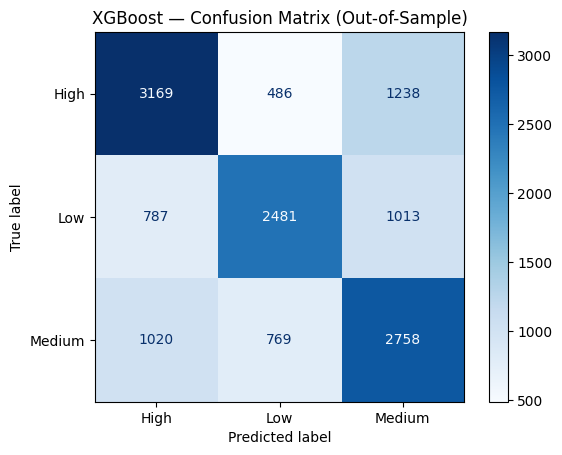

In [36]:
test_labels = np.unique(y_test)
cm = confusion_matrix(y_test, xgb_preds, labels=test_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_labels)
disp.plot(cmap="Blues")
plt.title("XGBoost — Confusion Matrix (Out-of-Sample)")
plt.grid(False)
plt.show()

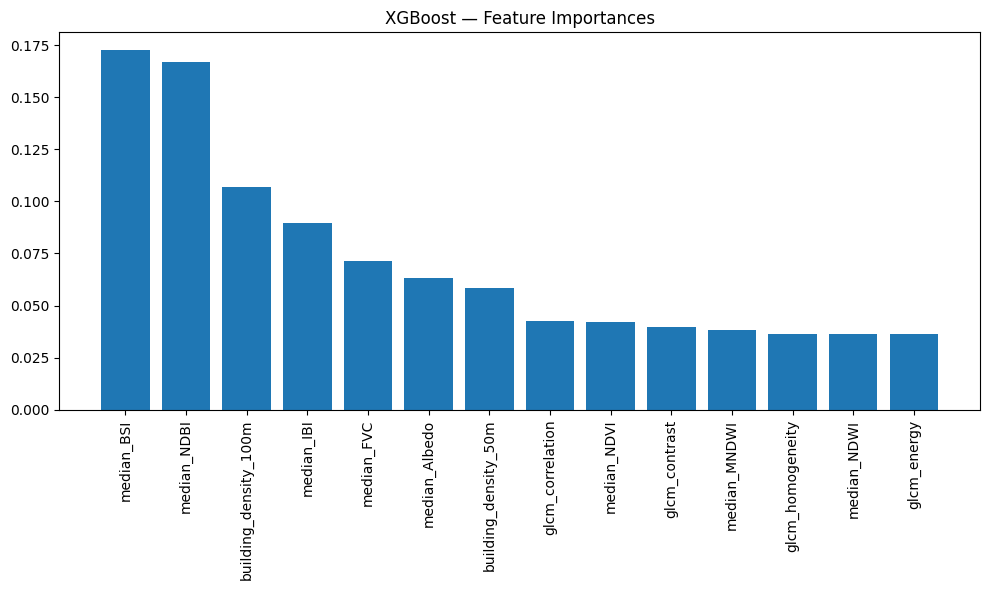

In [37]:
importances_xgb = xgb_model.feature_importances_
feature_names = train.drop(columns=["UHI_Class"]).columns
indices = np.argsort(importances_xgb)[::-1]

plt.figure(figsize=(10, 6))
plt.title("XGBoost — Feature Importances")
plt.bar(range(len(importances_xgb)), importances_xgb[indices], align="center")
plt.xticks(range(len(importances_xgb)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

### Model Validation on Freetown

In [38]:
#Reading the coordinates for the submission
test_file = pd.read_csv('./Data/Validation_Dataset.csv')
test_file.head()

,Longitude,Latitude,UHI_Class
0,-13.272932,8.447807,NaN
1,-13.272938,8.447757,NaN
2,-13.272997,8.447133,NaN
3,-13.273002,8.447015,NaN
4,-13.273007,8.446915,NaN


In [40]:
Sierra_heat_data = extract_band_vales(geotiff_path="./sample_Sierra.tiff", csv_input_path="./Data/Validation_Dataset.csv")
Sierra_heat_data.head()

Spectral + GLCM extraction: 100%|██████████| 14105/14105 [00:06<00:00, 2280.90it/s]


,Longitude,Latitude,UHI_Class,median_NDVI,median_NDBI,median_NDWI,median_MNDWI,median_Albedo,median_BSI,median_FVC,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,median_IBI
0,-13.272932,8.447807,NaN,0.089137,0.073610,-0.156911,-0.227235,0.259539,0.106905,0.003370,36.996854,0.200938,0.077823,0.459856,2.706160
1,-13.272938,8.447757,NaN,0.089137,0.073610,-0.156911,-0.227235,0.259539,0.106905,0.003370,36.996854,0.200938,0.077823,0.459856,2.706160
2,-13.272997,8.447133,NaN,0.149063,0.042776,-0.220591,-0.261059,0.256996,0.084003,0.019026,38.152211,0.199612,0.078697,0.470190,11.201209
3,-13.273002,8.447015,NaN,0.168755,0.036213,-0.240352,-0.275084,0.252202,0.079742,0.028854,38.331293,0.199269,0.077613,0.473835,174.004669
4,-13.273007,8.446915,NaN,0.144999,0.056791,-0.224965,-0.278362,0.250742,0.096774,0.016391,32.748810,0.211519,0.083964,0.514322,5.757555


In [41]:
SIERRA_DENSITY_CACHE = "./Data/sierra_building_density_cache.csv"

if os.path.exists(SIERRA_DENSITY_CACHE):
    print("Loading cached Sierra Leone building density...")
    Sierra_buildings_data = pd.read_csv(SIERRA_DENSITY_CACHE)
    Sierra_buildings_data = gpd.GeoDataFrame(
        Sierra_buildings_data,
        geometry=gpd.points_from_xy(Sierra_buildings_data.Longitude, Sierra_buildings_data.Latitude),
        crs="EPSG:4326"
    )
else:
    print("Computing Sierra Leone building density (one-time, will be cached)...")
    Sierra_buildings_data = compute_building_density(
        csv_path="./Data/Validation_Dataset.csv",
        buildings_shp_path="./Data/Sierra Leone Building Footprints/Sierra Leone_clipped.shp")
    Sierra_buildings_data.drop(columns='geometry', errors='ignore').to_csv(SIERRA_DENSITY_CACHE, index=False)
    print(f"Cached to {SIERRA_DENSITY_CACHE}")

Sierra_buildings_data.head()

Computing Sierra Leone building density (one-time, will be cached)...
Cached to ./Data/sierra_building_density_cache.csv


,Longitude,Latitude,UHI_Class,geometry,buffer_50,building_density_50m,buffer_100,building_density_100m
0,-13.272932,8.447807,NaN,POINT (-1477535.995 943831.442),"POLYGON ((-1477510.995 943806.442, -1477510.99...",0.0028,"POLYGON ((-1477485.995 943781.442, -1477485.99...",0.0015
1,-13.272938,8.447757,NaN,POINT (-1477536.736 943825.815),"POLYGON ((-1477511.736 943800.815, -1477511.73...",0.0028,"POLYGON ((-1477486.736 943775.815, -1477486.73...",0.0014
2,-13.272997,8.447133,NaN,POINT (-1477543.231 943755.665),"POLYGON ((-1477518.231 943730.665, -1477518.23...",0.0020,"POLYGON ((-1477493.231 943705.665, -1477493.23...",0.0010
3,-13.273002,8.447015,NaN,POINT (-1477543.787 943742.348),"POLYGON ((-1477518.787 943717.348, -1477518.78...",0.0020,"POLYGON ((-1477493.787 943692.348, -1477493.78...",0.0011
4,-13.273007,8.446915,NaN,POINT (-1477544.344 943731.094),"POLYGON ((-1477519.344 943706.094, -1477519.34...",0.0020,"POLYGON ((-1477494.344 943681.094, -1477494.34...",0.0011


In [ ]:
sierra_combined = pd.concat([
    Sierra_heat_data[SPECTRAL_COLS],
    Sierra_buildings_data[['building_density_100m', 'building_density_50m']]
], axis=1)

# Apply per-city normalisation to Freetown using its own statistics.
# Deviation features (dev_X) are excluded — they're already relative.
sierra_combined = per_city_normalize(sierra_combined, NORM_COLS)
print("Per-city spectral normalisation applied to Freetown.")

In [43]:
# Create a copy of the Sierra dataset for validation purposes to avoid modifying the original data
val_data=sierra_combined.copy()

In [44]:
val = val_data.loc[:, FEATURE_COLS]
print(f"Validation features: {list(val.columns)}")
val.head()

Validation features: ['median_NDVI', 'median_NDBI', 'median_NDWI', 'median_MNDWI', 'median_Albedo', 'median_BSI', 'median_FVC', 'median_IBI', 'building_density_100m', 'building_density_50m', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']


,median_NDVI,median_NDBI,median_NDWI,median_MNDWI,median_Albedo,median_BSI,median_FVC,median_IBI,building_density_100m,building_density_50m,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation
0,-0.208122,-0.559193,0.703723,1.425444,1.294292,-0.595333,-0.318495,-0.012216,0.0015,0.0028,36.996854,0.200938,0.077823,0.459856
1,-0.208122,-0.559193,0.703723,1.425444,1.294292,-0.595333,-0.318495,-0.012216,0.0014,0.0028,36.996854,0.200938,0.077823,0.459856
2,0.656467,-1.278221,-0.358532,0.673634,1.151194,-1.179053,0.176792,0.117331,0.0010,0.0020,38.152211,0.199612,0.078697,0.470190
3,0.940568,-1.431264,-0.688170,0.361924,0.881409,-1.287667,0.487693,2.600037,0.0011,0.0020,38.331293,0.199269,0.077613,0.473835
4,0.597831,-0.951387,-0.431501,0.289044,0.799241,-0.853561,0.093442,0.034317,0.0011,0.0020,32.748810,0.211519,0.083964,0.514322


In [45]:
# ── CRITICAL FIX: Apply the full preprocessing pipeline to Freetown ──────────
# Previously `sc.transform(val)` was called WITHOUT running imputer.transform()
# first. Any NaN values from raster edge pixels (very common in Freetown) were
# passed directly to XGBoost — silently corrupting predictions for those rows.
# The pipeline must match exactly what was applied to X_train:
#   raw features → impute NaNs (training medians) → StandardScaler

val_arr = imputer.transform(val)       # fill NaNs with training-city medians
val_transformed = sc.transform(val_arr)  # normalise to training-city scale
print(f"Freetown validation shape: {val_transformed.shape}")
print(f"NaN count after imputation: {np.isnan(val_transformed).sum()}")

Freetown validation shape: (14105, 14)
NaN count after imputation: 0


In [46]:
val_enc = xgb_model.predict(val_transformed)
val_preds = le.inverse_transform(val_enc)

xgb_submission = pd.DataFrame({
    "Longitude": test_file["Longitude"].values,
    "Latitude":  test_file["Latitude"].values,
    "UHI_Class": val_preds,
})
display(xgb_submission)
print(f"\nPrediction distribution:\n{xgb_submission['UHI_Class'].value_counts()}")

# Save Trial 06 predictions
xgb_submission.to_csv("./Data/Predicted_Dataset.csv", index=False)
xgb_submission.to_csv("./Data/Predicted_Dataset_T06.csv", index=False)
print("\nSaved: Predicted_Dataset.csv (submit this) and Predicted_Dataset_T06.csv (archive)")

,Longitude,Latitude,UHI_Class
0,-13.272932,8.447807,Medium
1,-13.272938,8.447757,Medium
2,-13.272997,8.447133,Low
3,-13.273002,8.447015,Low
4,-13.273007,8.446915,Low
...,...,...,...
14100,-13.252753,8.444992,High
14101,-13.214825,8.342432,High
14102,-13.215518,8.481770,High
14103,-13.206512,8.471898,High



Prediction distribution:
UHI_Class
High      6602
Medium    5583
Low       1920
Name: count, dtype: int64

Saved: Predicted_Dataset.csv (submit this) and Predicted_Dataset_T06.csv (archive)
